Загрузка данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('train.csv')

Знакомство с датасетом

In [ ]:
df.shape

In [4]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [5]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


Анализ пассажиров

In [6]:
df['Pclass'].value_counts().sort_index()

,count
Pclass,
1,216
2,184
3,491


кол-во пассажиров по классам

In [7]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


Количество мужчин и женщин

In [8]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Дети (0-12)', 'Подростки (13-18)', 'Молодые взрослые (19-35)', 'Взрослые (36-60)', 'Пожилые (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
df['AgeGroup'].value_counts()

,count
AgeGroup,
Молодые взрослые (19-35),366
Взрослые (36-60),209
Дети (0-12),68
Подростки (13-18),45
Пожилые (60+),26


In [9]:
round(df['Age'].mean(), 2)

np.float64(29.7)

средний возраст

In [10]:
df['Age'].median()

28.0

медиана возраста

In [11]:
round(df['Fare'].mean(), 2)

np.float64(32.2)

средняя стоимость билета

Сравнение пассажиров разных классов

In [12]:
df.groupby('Pclass')['Fare'].mean()

,Fare
Pclass,
1,84.154687
2,20.662183
3,13.675550


средняя стоимость по классам

In [13]:
df.groupby('Pclass')['Age'].mean().round(2)

,Age
Pclass,
1,38.23
2,29.88
3,25.14


средний возраст по классам

In [18]:
df.groupby(['Pclass', 'Sex']).size().unstack()

Sex,female,male
Pclass,,
1,94,122
2,76,108
3,144,347


количество муж и жен в каждом классе

In [23]:
max_pclass = df['Pclass'].value_counts().idxmax()
print(f"Больше всего пассажиров было в {max_pclass} классе.")

Больше всего пассажиров было в 3 классе.


Пассажиры 1 класса в среднем старше 38 и платили больше чем  3 класс. Многие были в 3 классе и большенсто там - это мужчины.

In [26]:
max_fare_idx = df['Fare'].idxmax()
most_expensive = df.loc[max_fare_idx, ['Pclass', 'Age', 'Sex', 'Survived', 'Fare']]
print( most_expensive)

Pclass             1
Age             35.0
Sex           female
Survived           1
Fare        512.3292
Name: 258, dtype: object


Анализ выживаемости

In [27]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


общее кол-во выживших и погибших

In [28]:
df.groupby('Sex')['Survived'].mean().round(3)

,Survived
Sex,
female,0.742
male,0.189


выживаемость

In [31]:
df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack().round(3)

Sex,female,male
Pclass,,
1,0.968,0.369
2,0.921,0.157
3,0.500,0.135


выживаемоть для каждого класса и пола

In [35]:
survival_rates = df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
best_group = survival_rates.loc[survival_rates['Survived'].idxmax()]
print(f"Наибольшая доля выживших: Женщины 1-го класса ({best_group['Survived']:.1%}")


Наибольшая доля выживших: Женщины 1-го класса (96.8%


Визуализация

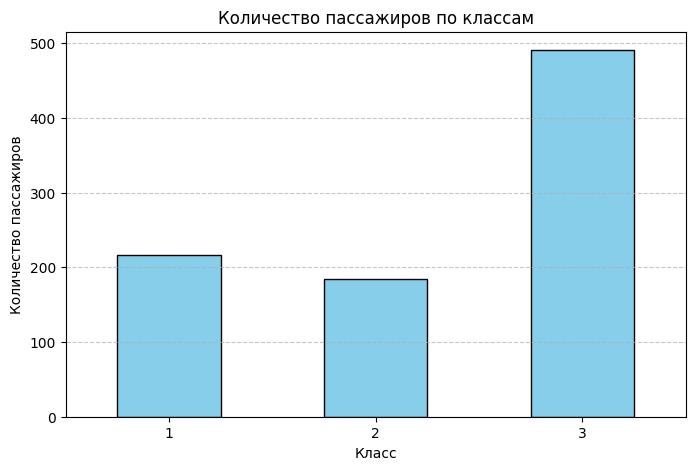

In [36]:
plt.figure(figsize=(8, 5))
df['Pclass'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

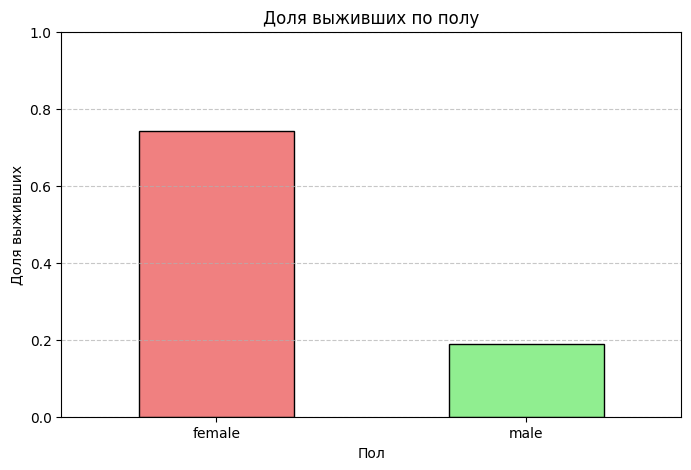

In [37]:
plt.figure(figsize=(8, 5))
survival_by_sex = df.groupby('Sex')['Survived'].mean()
survival_by_sex.plot(kind='bar', color=['lightcoral', 'lightgreen'], edgecolor='black')
plt.title('Доля выживших по полу')
plt.xlabel('Пол')
plt.ylabel('Доля выживших')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

свой вопрос

In [39]:
df['HasRelatives'] = (df['SibSp'] + df['Parch']) > 0
survival_by_relatives = df.groupby('HasRelatives')['Survived'].mean()

In [40]:
print(f"Доля выживших БЕЗ родственников: {survival_by_relatives[False]:.1%}")
print(f"Доля выживших С родственниками:  {survival_by_relatives[True]:.1%}")

Доля выживших БЕЗ родственников: 30.4%
Доля выживших С родственниками:  50.6%


у выживших у которых есть родственникишансы выжить выше, хотя мне кажется что это просто совпадение